In [ ]:
import pandas as pd
import numpy as np

# === 1. Load ===
pairs_df = pd.read_csv("pairs_df.csv")
compounds_df = pd.read_csv("compounds.csv")

# === 2. Normalize column names ===
pairs_df.columns = pairs_df.columns.str.strip().str.lower()
compounds_df.columns = compounds_df.columns.str.strip().str.lower()

# === 3. Identify ID and SMILES columns ===
mol_id_col = "id" if "id" in compounds_df.columns else compounds_df.columns[0]
smiles_col = "smiles" if "smiles" in compounds_df.columns else compounds_df.columns[1]

# === 4. Add SMILES ===
merged = pairs_df.merge(compounds_df[[mol_id_col, smiles_col]], left_on="mol1", right_on=mol_id_col)
merged = merged.merge(compounds_df[[mol_id_col, smiles_col]], left_on="mol2", right_on=mol_id_col, suffixes=("_mol1", "_mol2"))

# ✅ FILTER out separation == -1
merged = merged[merged["separation"] != -1]

# === 5. Keep and sort by the separation column ===
merged = merged[["mol1", "smiles_mol1", "mol2", "smiles_mol2", "separation"]]

# Extract unique compounds that have corresponding entries in both 'mol1' and 'mol2' columns
unique_compounds_mol1 = merged["mol1"].unique()
unique_compounds_mol2 = merged["mol2"].unique()

# Find the intersection of unique compounds in both columns
valid_compounds = np.intersect1d(unique_compounds_mol1, unique_compounds_mol2)

# Extract existing pairs
existing_pairs = set(zip(merged["mol1"], merged["mol2"]))

# Generate random pairs of compounds that are not already in the dataset
random_pairs = []
while len(random_pairs) < 600:
    mol1, mol2 = np.random.choice(valid_compounds, size=2, replace=False)
    if (mol1, mol2) not in existing_pairs:
        random_pairs.append((mol1, mol2))
        existing_pairs.add((mol1, mol2))

merged = merged.sort_values(by="separation").reset_index(drop=True)

# Create new rows for the random pairs
new_rows = [
    {
        "mol1": pair[0],
        "smiles_mol1": merged.loc[merged["mol1"] == pair[0], "smiles_mol1"].iloc[0],
        "mol2": pair[1],
        "smiles_mol2": merged.loc[merged["mol2"] == pair[1], "smiles_mol2"].iloc[0],
        "separation": "random pairs"
    }
    for pair in random_pairs
]

# Append the new rows to the DataFrame
merged = pd.concat([merged, pd.DataFrame(new_rows)], ignore_index=True)

# === 6. Export ===
merged.to_csv("merged_pairs_with_smiles.csv", index=False)

print("✅ Dataset created: 'merged_pairs_with_smiles.csv'")

✅ Dataset criado: 'merged_pairs_with_smiles.csv'


Ciclo for para ir buscar os 2 smiles ao dataset:

In [ ]:
import pandas as pd
import numpy as np
from rdkit.Chem import MolFromSmiles
from deepmol.compound_featurization import NPClassifierFP, BiosynfoniKeys, NeuralNPFP, MHFP, MorganFingerprint
from deepmol.compound_featurization import LLM
from tqdm import tqdm
from transformers import BertConfig, BertModel, ModernBertModel, ModernBertConfig 
from deepmol.tokenizers import NPBERTTokenizer
import os



# === 1. Load the dataset ===
df = pd.read_csv("merged_pairs_with_smiles.csv")

# === 2. List of featurizers ===
featurizers = {
    "NPClassifierFP": NPClassifierFP(),
    "Biosynfoni": BiosynfoniKeys(),
    "NP_AUX": NeuralNPFP(),
    "MorganFP": MorganFingerprint(),
    "NPBERT": LLM(model_path="../NPBERT", model=BertModel, config_class=BertConfig,
                          tokenizer=NPBERTTokenizer(vocab_file=os.path.join("../NPBERT", "vocab.txt")), device="cpu"),
    "ModernBERT": LLM(model_path="../ModernBERT", model=ModernBertModel, config_class=ModernBertConfig, device="cuda:1")
}
similarity_metric = "cosine"

# === 3. Similarity functions ===
def cosine_similarity(v1, v2):
    dot_product = np.dot(v1, v2)
    norm_product = np.linalg.norm(v1) * np.linalg.norm(v2)
    if norm_product == 0:
        return 0
    return dot_product / norm_product

def counted_tanimoto_similarity(x, y):
    """
    Compute counted Tanimoto similarity between two vectors.
    Parameters:
        x, y : array-like
            Input vectors (must be the same length).
    Returns:
        float : Similarity score between 0 and 1.
    """
    x = np.array(x)
    y = np.array(y)
    
    intersection = np.sum(np.minimum(x, y))
    union = np.sum(np.maximum(x, y))
    
    if union == 0:
        return np.nan  
    
    return intersection / union

def tanimoto_similarity(a, b):
    """
    Compute Tanimoto similarity between two binary vectors a and b.

    Parameters:
    a, b : numpy.ndarray
        Binary vectors (1D arrays) of the same length.

    Returns:
    float: Tanimoto similarity between a and b.
    """
    intersection = float(np.count_nonzero(a[a == b]))
    union = float(np.count_nonzero(a) + np.count_nonzero(b) - intersection)
    return intersection / union if union != 0 else 0.0

def apply_to_featurizers(similarity_metric):
# === 4. Apply each featurizer ===
    for name, featurizer in featurizers.items():
        print(f"🔄 Computing similarity with: {name}")
        similarities = []

        for idx, row in tqdm(df.iterrows(), total=len(df), desc=f"Computing similarities for {name}"):
            smile1 = row["smiles_mol1"]
            smile2 = row["smiles_mol2"]

            if name in ["NPClassifierFP", "Biosynfoni", "NP_AUX", "MHFP", "MorganFP"]:
                mol1 = MolFromSmiles(smile1)
                mol2 = MolFromSmiles(smile2)

                if mol1 and mol2:
                    try:
                        fp1 = featurizer._featurize(mol1)
                        fp2 = featurizer._featurize(mol2)
                        fp1 = fp1.astype('float64')
                        fp2 = fp2.astype('float64')

                        if similarity_metric == "tanimoto":
                            if name in ["NPClassifierFP", "Biosynfoni"]:
                                sim = counted_tanimoto_similarity(fp1, fp2)
                            else:
                                sim = tanimoto_similarity(fp1, fp2)
                        elif similarity_metric == "cosine":
                            sim = cosine_similarity(fp1, fp2)

                    except Exception as e:
                        sim = 0
                else:
                    sim = 0

            else:
                try:
                    fp1 = featurizer._featurize(smile1)
                    fp2 = featurizer._featurize(smile2)
                    fp1 = fp1.astype('float64')
                    fp2 = fp2.astype('float64')
                    sim = cosine_similarity(fp1, fp2)
                except Exception as e:
                    sim = 0

            similarities.append(sim)

        df[name] = similarities

    df.to_csv(f"merged_pairs_with_all_fps_{similarity_metric}.csv", index=False)

similarity_metric = "cosine"
apply_to_featurizers(similarity_metric)

similarity_metric = "tanimoto"
apply_to_featurizers(similarity_metric)

Calculando similaridades para NPClassifierFP: 100%|██████████| 4297/4297 [00:09<00:00, 438.65it/s]


🔄 A calcular similaridade com: Biosynfoni


Calculando similaridades para Biosynfoni: 100%|██████████| 4297/4297 [00:08<00:00, 536.95it/s]


🔄 A calcular similaridade com: MHFP


Calculando similaridades para MHFP:   0%|          | 8/4297 [00:00<00:57, 74.17it/s]/home/jcapela/.local/share/mamba/envs/np_benchmark/lib/python3.10/site-packages/deepmol/compound_featurization/_mhfp.py:305: UserWarning: The length of the shingling is 0, which results in an empty set and an all zero folded fingerprint.
  warnings.warn(
Calculando similaridades para MHFP: 100%|██████████| 4297/4297 [01:06<00:00, 64.26it/s] 


🔄 A calcular similaridade com: MorganFP


Calculando similaridades para MorganFP: 100%|██████████| 4297/4297 [00:09<00:00, 440.83it/s]


In [5]:
import pandas as pd

# === 1. Carregar o dataset ===
df = pd.read_csv("merged_pairs_with_all_fps_cosine.csv")

# === 2. Remover WATER e PROTON ===
df = df[~df["mol1"].isin(["WATER", "PROTON"]) & ~df["mol2"].isin(["WATER", "PROTON"])]

# === 3. Contar frequência total de cada molécula ===
mol_counts = pd.concat([df["mol1"], df["mol2"]]).value_counts()

# === 4. Determinar moléculas muito repetidas (top 1%) ===
threshold = mol_counts.quantile(0.99)
frequent_mols = mol_counts[mol_counts > threshold].index

# === 5. Remover pares com moléculas muito frequentes ===
df = df[~df["mol1"].isin(frequent_mols) & ~df["mol2"].isin(frequent_mols)]

# === 6. Guardar dataset filtrado ===
df.to_csv("filtered_pairs_removed_water_proton_repetidos_cosine.csv", index=False)

print("✅ Ficheiro salvo como 'filtered_pairs_removed_water_proton_repetidos.csv'")


✅ Ficheiro salvo como 'filtered_pairs_removed_water_proton_repetidos.csv'


Dar clean ao dataset
remove proton, water e o top 1% de frequencia

In [6]:
import pandas as pd

# === 1. Carregar o dataset ===
df = pd.read_csv("merged_pairs_with_all_fps_tanimoto.csv")

# === 2. Remover WATER e PROTON ===
df = df[~df["mol1"].isin(["WATER", "PROTON"]) & ~df["mol2"].isin(["WATER", "PROTON"])]

# === 3. Contar frequência total de cada molécula ===
mol_counts = pd.concat([df["mol1"], df["mol2"]]).value_counts()

# === 4. Determinar moléculas muito repetidas (top 1%) ===
threshold = mol_counts.quantile(0.99)
frequent_mols = mol_counts[mol_counts > threshold].index

# === 5. Remover pares com moléculas muito frequentes ===
df = df[~df["mol1"].isin(frequent_mols) & ~df["mol2"].isin(frequent_mols)]

# === 6. Guardar dataset filtrado ===
df.to_csv("filtered_pairs_removed_water_proton_repetidos_tanimoto.csv", index=False)

print("✅ Ficheiro salvo como 'filtered_pairs_removed_water_proton_repetidos.csv'")


✅ Ficheiro salvo como 'filtered_pairs_removed_water_proton_repetidos.csv'


Gráfico

Plotting separation: 1, n=609
Plotting separation: 2, n=503
Plotting separation: 3, n=436
Plotting separation: 4, n=367
Plotting separation: 5, n=294
Plotting separation: 6, n=216
Plotting separation: random pairs, n=587


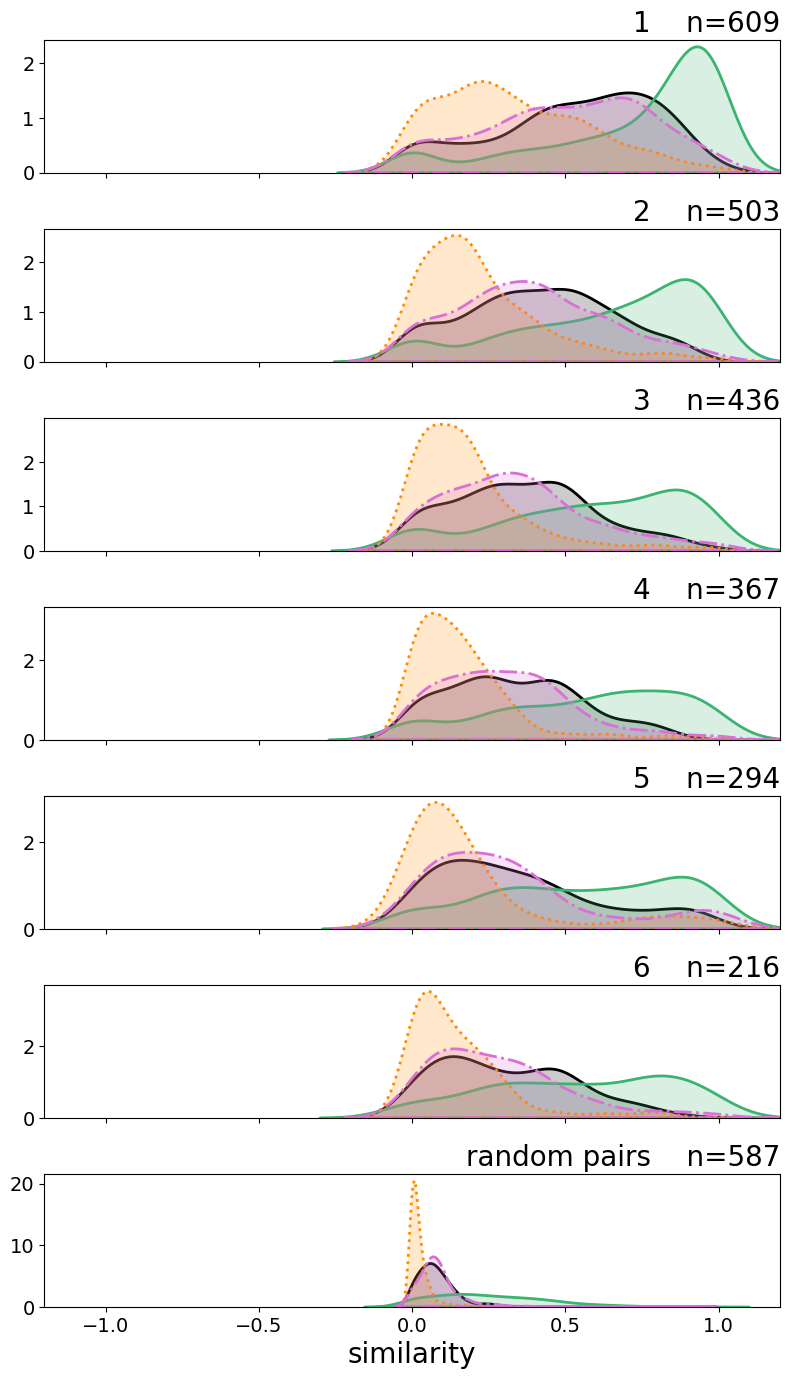

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Load the dataset
df = pd.read_csv("filtered_pairs_removed_water_proton_repetidos_tanimoto.csv")

# Define fingerprints to use
# fps_all = ["NPClassifierFP", "Biosynfoni", "NP_AUX", "MHFP", "MorganFP", "NPBERT"]
fps_all = ["NPClassifierFP", "Biosynfoni", "MHFP", "MorganFP"]
fps = [fp for fp in fps_all if fp in df.columns]

# Define colors and linestyles
colors = {
    "NPClassifierFP": "black",
    "Biosynfoni": "mediumseagreen",
    "NP_AUX": "royalblue",
    "MHFP": "darkorange",
    "MorganFP": "orchid",
    "NPBERT": "slategray",
    # "ModernBERT": "darkviolet"
}

linestyles = {
    "NPClassifierFP": "-",
    "Biosynfoni": "-",
    "NP_AUX": "--",
    "MHFP": ":",
    "MorganFP": "-.",
    "NPBERT": (0, (3, 1, 1, 1)),
    # "ModernBERT": (0, (1, 1))
}

# Convert columns to numeric
# for fp in fps:
#     df[fp] = pd.to_numeric(df[fp], errors="coerce")

# Create the main plot
fig, axes = plt.subplots(7, 1, figsize=(8, 14), sharex=True)
for i, sep in enumerate([1, 2, 3, 4, 5, 6, "random pairs"]):
    ax = axes[i]
    subset = df[df["separation"] == str(sep)]
    print(f"Plotting separation: {sep}, n={len(subset)}")
    for fp in fps:
        if fp in subset.columns:
            sns.kdeplot(
                data=subset[fp].dropna(),
                ax=ax,
                label=fp if i == 0 else "",
                linewidth=2,
                linestyle=linestyles[fp],
                color=colors[fp],
                fill=True,
                alpha=0.2
            )
    ax.set_title(f"{sep}    n={len(subset)}", loc='right', fontsize=20)
    ax.set_xlim(-1.2, 1.2)
    ax.set_ylabel("")
    if i < 6:
        ax.set_xlabel("")
    ax.tick_params(axis='both', which='major', labelsize=14)
axes[-1].set_xlabel("similarity", size=20)

plt.tight_layout()
plt.subplots_adjust(top=0.96)

# Save the main plot
plt.savefig("fingerprint_similarity_distributions_tanimoto.png", dpi=300, transparent=True)
plt.show()
plt.close()

# Create a separate figure for the legend
fig_legend = plt.figure(figsize=(6, 2))
legend_handles = [
    plt.Line2D([0], [0], color=colors[fp], linestyle=linestyles[fp], linewidth=2)
    for fp in fps
]
fig_legend.legend(legend_handles, fps, title="NP representation", loc="center", ncol=2)
fig_legend.savefig("legend.png", bbox_inches='tight', dpi=300, transparent=True)
plt.close(fig_legend)


Plotting separation: 1, n=609
Plotting separation: 2, n=503
Plotting separation: 3, n=436
Plotting separation: 4, n=367
Plotting separation: 5, n=294
Plotting separation: 6, n=216
Plotting separation: random pairs, n=587


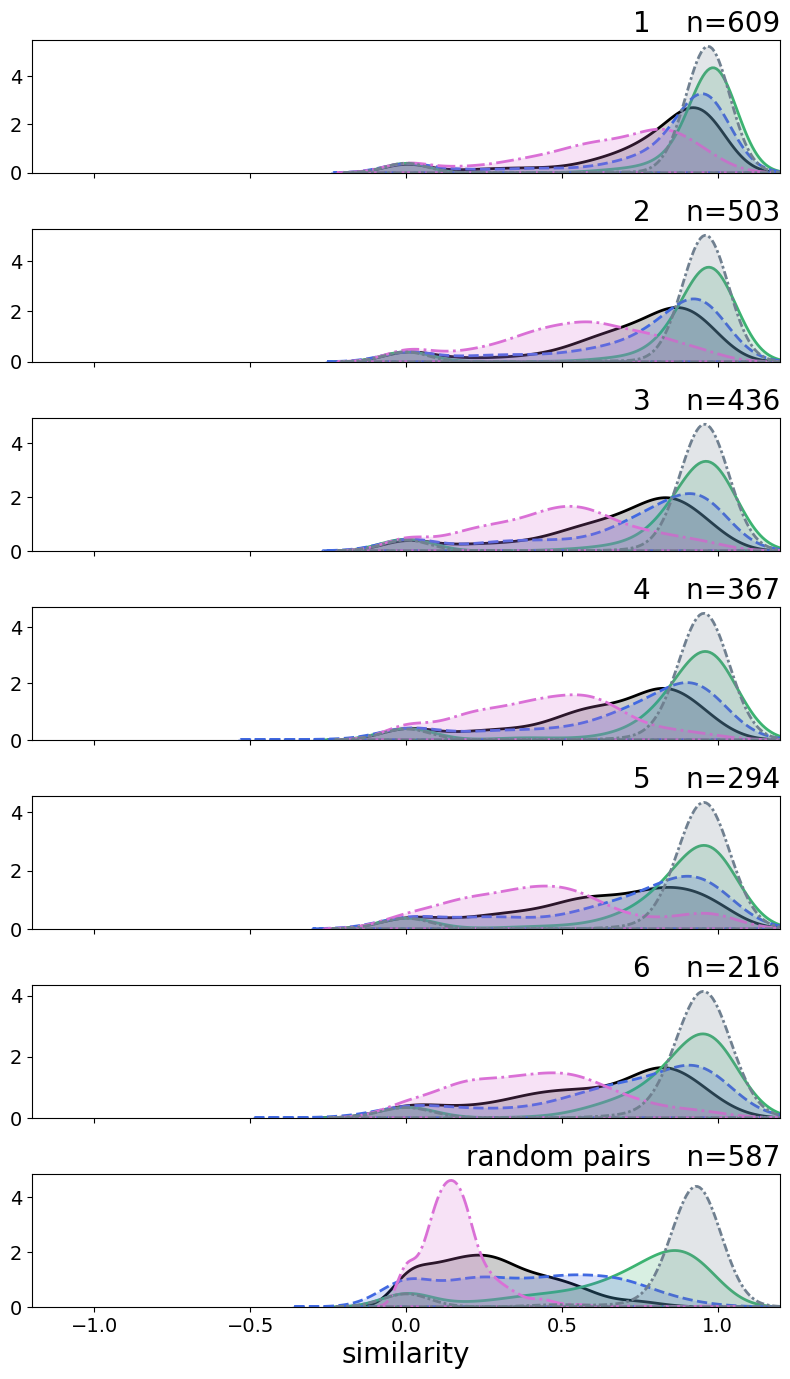

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Load the dataset
df = pd.read_csv("filtered_pairs_removed_water_proton_repetidos_cosine.csv")

# Define fingerprints to use
fps_all = ["NPClassifierFP", "Biosynfoni", "NP_AUX", "MorganFP", "NPBERT"]
# fps_all = ["NPClassifierFP", "Biosynfoni", "MHFP", "MorganFP"]
fps = [fp for fp in fps_all if fp in df.columns]

# Define colors and linestyles
colors = {
    "NPClassifierFP": "black",
    "Biosynfoni": "mediumseagreen",
    "NP_AUX": "royalblue",
    "MHFP": "darkorange",
    "MorganFP": "orchid",
    "NPBERT": "slategray",
    # "ModernBERT": "darkviolet"
}

linestyles = {
    "NPClassifierFP": "-",
    "Biosynfoni": "-",
    "NP_AUX": "--",
    "MHFP": ":",
    "MorganFP": "-.",
    "NPBERT": (0, (3, 1, 1, 1)),
    # "ModernBERT": (0, (1, 1))
}

# Convert columns to numeric
# for fp in fps:
#     df[fp] = pd.to_numeric(df[fp], errors="coerce")

# Create the main plot
fig, axes = plt.subplots(7, 1, figsize=(8, 14), sharex=True)
for i, sep in enumerate([1, 2, 3, 4, 5, 6, "random pairs"]):
    ax = axes[i]
    subset = df[df["separation"] == str(sep)]
    print(f"Plotting separation: {sep}, n={len(subset)}")
    for fp in fps:
        if fp in subset.columns:
            sns.kdeplot(
                data=subset[fp].dropna(),
                ax=ax,
                label=fp if i == 0 else "",
                linewidth=2,
                linestyle=linestyles[fp],
                color=colors[fp],
                fill=True,
                alpha=0.2
            )
    ax.set_title(f"{sep}    n={len(subset)}", loc='right', fontsize=20)
    ax.set_xlim(-1.2, 1.2)
    ax.set_ylabel("")
    if i < 6:
        ax.set_xlabel("")

    ax.tick_params(axis='both', which='major', labelsize=14)
axes[-1].set_xlabel("similarity", size=20)

plt.tight_layout()
plt.subplots_adjust(top=0.96)

# Save the main plot
plt.savefig("fingerprint_similarity_distributions_cosine.png", dpi=300, transparent=True)
plt.show()
plt.close()

# Create a separate figure for the legend
fig_legend = plt.figure(figsize=(6, 2))
legend_handles = [
    plt.Line2D([0], [0], color=colors[fp], linestyle=linestyles[fp], linewidth=2)
    for fp in fps
]
fig_legend.legend(legend_handles, fps, title="NP representation", loc="center", ncol=1)
fig_legend.savefig("legend.png", bbox_inches='tight', dpi=300, transparent=True)
plt.close(fig_legend)


In [2]:
df

,mol1,smiles_mol1,mol2,smiles_mol2,separation,NPClassifierFP,Biosynfoni,NP_AUX,MHFP,MorganFP,NPBERT,ModernBERT
0,CPD-22270,C[C@H]1(CN[C@@]2(CC1)([C@@H](C)C3([C@@H](O2)CC...,CPD-22269,C[C@H]1(CN[C@@]2(CC1)([C@@H](C)C3([C@@H](O2)CC...,1,0.965393,0.999898,0.972011,-0.368492,0.827535,0.975465,0.999942
1,CPDQT-32,CSCCCCC(O)(CC([O-])=O)C(=O)[O-],CPD-19478,CSCCCCC(\C(=O)[O-])=C\C([O-])=O,1,0.816371,0.961055,0.931913,-0.028929,0.555556,0.936253,0.999657
2,CPD-19490,CSCCCCC(C(=O)C(=O)[O-])C(=O)[O-],CPDQT-28,CSCCCCCC(=O)C([O-])=O,1,0.822724,0.970098,0.954972,0.117996,0.656488,0.971328,0.999553
3,CPDQT-28,CSCCCCCC(=O)C([O-])=O,CPDQT-33,CSCCCCCC(O)(CC([O-])=O)C(=O)[O-],1,0.860122,0.969570,0.948356,0.071999,0.644658,0.972861,0.999610
4,CPD-19479,CSCCCCCC(\C(=O)[O-])=C\C([O-])=O,CPDQT-38,CSCCCCCC(C(O)C(=O)[O-])C(=O)[O-],1,0.819813,0.979762,0.940155,-0.088806,0.571429,0.966775,0.999588
...,...,...,...,...,...,...,...,...,...,...,...,...
3007,CPD-16623,C[C@]1(C=O)([C@@H](O)C[C@@]3(C)([C@@H](C1)[C@@...,CPD-17478,C3(/C=C(\C=C/C(/C(OO)C1(OC2(\C(\C(=O)1)=C/C=C(...,random pairs,0.528358,0.671547,0.365072,0.577557,0.297812,0.919744,0.941827
3008,CPD-17443,C=CCSC[C@@H](C([O-])=O)NC(=O)CC[C@H]([NH3+])C(...,CPD-15074,C3(/C=C(\C=C/C(/C1(O)(OC2(\C(\C(=O)C1)=C(/C=C(...,random pairs,0.128023,0.931520,0.639552,-0.162028,0.160014,0.931875,0.992295
3009,CPD-21171,C(NC(SC[C@@H](C([O-])=O)[NH3+])=S)C1(\C2(/C=C\...,CPD-5168,CC(C)=CCCC(\C)=C/CCC(\C)=C/CCC(/C)=C/CCC(/C)=C...,random pairs,0.182198,0.771098,0.013659,0.530807,0.130814,0.498912,0.276479
3010,CPDQT-341,CSCCCC/C=N/O,CPDQT-286,CSCCCCCC(/S[C@@H]1(O[C@H](CO)[C@@H](O)[C@H](O)...,random pairs,0.562676,0.691898,0.803060,0.204578,0.413795,0.952894,0.994866
